In [2]:
import pandas as pd
import json
from pathlib import Path
from datetime import datetime

In [3]:
# load the scans I want to fill and their paths

list_for_yaniv_pixeled = pd.read_csv("/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/list_for_yaniv_pixeled.csv")
list_for_yaniv_partial_scans = pd.read_csv("/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/list_for_yaniv_partial_scans.csv")

In [4]:
print(list_for_yaniv_pixeled.columns)

Index(['subject_id', 'session_id', 'file_path'], dtype='str')


pseudocode: 
1. in the file path - all the path until '/derivatives/*' +  subject_id + session_id + anat
find the json file
read from it the AcquisitionTime (it's in the format hh:mm:ss.msmsms)
add to the pd a column called 'scan_time' with the hour and minute in the format 'hhmm'

2. create a list of full session_ids, that are built like this: session_id+scan_time. the output should be a list of str in the format 'yyyymmddhhss'

In [5]:
def get_scan_time(row):
    try:
        # 1. Build the path dynamically
        # Logic: Everything up to /derivatives/ + sub + ses + anat
        base_path = row['file_path'].split('/derivatives/')[0]
        folder_path = Path(base_path) / row['subject_id'] / row['session_id'] / 'anat'
        
        # Find the first json file in that directory
        json_file = next(folder_path.glob('*.json'))
        
        with open(json_file, 'r') as f:
            data = json.load(f)
            # Format is hh:mm:ss.msmsms
            raw_time = data.get('AcquisitionTime', '00:00:00.000000')
            
            # Parse and convert to 'hhmm'
            t = datetime.strptime(raw_time.split('.')[0], '%H:%M:%S')
            return t.strftime('%H%M')
            
    except (StopIteration, FileNotFoundError, KeyError, ValueError):
        # Return a placeholder if file is missing or path is malformed
        return "0000"

add scan time (and create a full session id) for manually labeled scans (pixeled and partial) - for Yaniv to find better versions of them

In [6]:
def process_and_save_scans(df, scan_type):
    """
    Cleans data, extracts scan time, and saves the full session IDs to a CSV.
    """
    # 1. Clean columns in bulk
    cols_to_fix = ['file_path', 'subject_id', 'session_id']
    df[cols_to_fix] = df[cols_to_fix].fillna('').astype(str)

    # 2. Add 'scan_time'
    df['scan_time'] = df.apply(get_scan_time, axis=1)

    # 3. Create full session IDs
    full_ids = (df['session_id'] + df['scan_time']).to_frame(name='full_session_id')

    # 4. Save to CSV
    output_path = f"/home/gaia/Projects/legacy_data/full_session_ids_{scan_type}.csv"
    # full_ids.to_csv(output_path, index=False)
    
    print(f"Success: Processed {scan_type}. Sample: {full_ids['full_session_id'].iloc[0]}")
    return full_ids

# Use the function for both datasets
full_session_ids_partial_scans = process_and_save_scans(list_for_yaniv_partial_scans, "partial_scans")
full_session_ids_pixeled = process_and_save_scans(list_for_yaniv_pixeled, "pixeled")

Success: Processed partial_scans. Sample: ses-200906021944
Success: Processed pixeled. Sample: ses-200711201714


In [ ]:
combined_df = pd.read_pickle('/home/gaia/Projects/legacy_data/best_combined_gm_volumes.pkl')


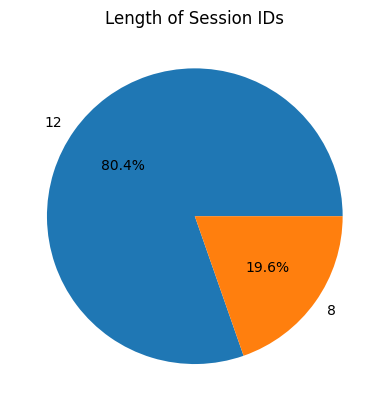

In [10]:
# are there missing session_id in combined_df?
# plot a pie chart of the len of session_id (how many characters in the str)
import matplotlib.pyplot as plt

session_id_lengths = combined_df['session_id'].str.len()
plt.pie(session_id_lengths.value_counts(), labels=session_id_lengths.value_counts().index, autopct='%1.1f%%')
plt.title('Length of Session IDs')
plt.show()

this is not working yet, because I don't have the json file path in combined_df so it doesn't know where to look for the files. 
need to fill the pathes according to the source (each source and it's own path)  

In [ ]:
import pandas as pd
import json
from pathlib import Path

def extract_json_metadata(df, target_field='AcquisitionTime', new_col='scan_time'):
    """
    Efficiently extracts metadata from BIDS JSON files for large DataFrames.
    """
    # 1. Create a unique list of subject/session folders to avoid redundant disk lookups
    # We group by the folder path so we only search for the JSON once per session
    df['temp_folder'] = df.apply(
        lambda x: str(Path(x['file_path'].split('/derivatives/')[0])  / 'sub-' + x['subject_id'] / 'ses-'+ x['session_id'] / 'anat'), 
        axis=1
    )
    
    unique_folders = df['temp_folder'].unique()
    cache = {}

    print(f"Searching metadata for {len(unique_folders)} unique sessions...")

    for folder in unique_folders:
        try:
            # Find the first json file in the folder
            json_path = next(Path(folder).glob('*.json'))
            with open(json_path, 'r') as f:
                data = json.load(f)
                val = data.get(target_field, None)
                
                # Special formatting logic for AcquisitionTime
                if target_field == 'AcquisitionTime' and val:
                    # '12:30:05.123' -> '1230'
                    val = val.replace(':', '').split('.')[0][:4]
                
                cache[folder] = val if val is not None else "0000"
        except (StopIteration, FileNotFoundError, Exception):
            cache[folder] = "0000"

    # 2. Map the cached values back to the main dataframe (Vectorized-style mapping)
    df[new_col] = df['temp_folder'].map(cache)
    
    # Clean up
    df.drop(columns=['temp_folder'], inplace=True)
    return df

# --- How to use it for 3 million rows ---

# To get AcquisitionTime (default)
# df = extract_json_metadata(df, target_field='AcquisitionTime', new_col='scan_time')

# To get MagneticFieldStrength
df = extract_json_metadata(df, target_field='MagneticFieldStrength', new_col='tesla')